# Phase 1: Exploratory Data Analysis & Target Cohort Definition
## Project: Institutional Credit Risk Scoring Pipeline (Champion-Challenger Framework)

### 1. Objective
The objective of this notebook is to ingest raw peer-to-peer lending data, perform exploratory data analysis, isolate the core risk features, and construct a clean performance cohort. This step establishes the foundational data integrity before engineering features or training predictive engines.

### 2. Credit Risk Target Formulation
In retail banking, credit risk is framed as a binary classification problem: predicting the Probability of Default (PD). To train a stable model, we must establish a clear performance window and filter out ambiguous loan statuses.

* **Target = 0 (Good Borrower):** Loans that have been completely paid off (`Fully Paid`).
* **Target = 1 (Bad Borrower / Default):** Loans that represent a severe credit loss (`Charged Off`, `Default`).
* **Exclusions:** Active, in-grace-period, or late loans (e.g., `Current`, `Late (31-120 days)`) are excluded from training because their final economic outcome is not yet known. Inverting this or including them introduces severe performance-window bias.

### 3. Pipeline Steps in this Notebook
1. **Data Ingestion & Schema Audit:** Scanning raw features (`grade`, `purpose`, `annual_inc`, `int_rate`, `loan_amnt`).
2. **Target Filtering:** Executing the performance cohort isolation ($y \in \{0, 1\}$).
3. **Descriptive Baseline Statistics:** Visualizing distributions, calculating baseline default rates, and checking for initial feature anomalies or outliers.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for finance reports
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Define paths - assuming running from the notebooks/ directory
RAW_DATA_PATH = "data/raw/accepted_2007_to_2018Q4.csv.gz" # Adjust filename if necessary
PROCESSED_DATA_DIR = "data/processed"

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

print("Pipeline environment initialized successfully.")

Pipeline environment initialized successfully.


In [2]:
cols_to_use = [
    'loan_status', 'issue_d',
    'recoveries', 'total_rec_prncp',
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose',
    'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths',
    'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'annual_inc_joint', 'dti_joint',
    'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths',
    'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
    'mort_acc', 'num_accts_ever_120_pd', 'num_actv_rev_tl'
]

df_raw = pd.read_csv(RAW_DATA_PATH, usecols=cols_to_use, low_memory=False)
print(f"Raw shape loaded: {df_raw.shape}")
df_raw.head()

Raw shape loaded: (2260701, 51)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,num_accts_ever_120_pd,num_actv_rev_tl
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,...,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,2.0,4.0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,...,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,0.0,5.0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,...,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,0.0,3.0
3,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,...,12.1,0.0,0.0,36.0,87.0,2.0,2.0,1.0,0.0,5.0
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,...,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,0.0,6.0


In [3]:
# Audit the categorical distributions of loan status before filtering
print("=== RAW LOAN STATUS DISTRIBUTION ===")

print(df_raw['loan_status'].value_counts(dropna=False))

=== RAW LOAN STATUS DISTRIBUTION ===
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64


In [4]:
target_map = {
    'Fully Paid'  : 0,
    'Charged Off' : 1,
    'Default'     : 1
}


df_raw['int_rate']   = pd.to_numeric(df_raw['int_rate'].astype(str).str.rstrip('%'),   errors='coerce')
df_raw['revol_util'] = pd.to_numeric(df_raw['revol_util'].astype(str).str.rstrip('%'), errors='coerce')

df_filtered = df_raw[df_raw['loan_status'].isin(target_map.keys())].copy()
df_filtered['target'] = df_filtered['loan_status'].map(target_map)

# --- Imputation strategy ---
# NaN in months-since-* means the event NEVER occurred — informative absence, not random
# missing. Sentinel 999 preserves that signal; WoE will assign it its own bin.
sentinel_cols = ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog']
df_filtered[sentinel_cols] = df_filtered[sentinel_cols].fillna(999)

# Joint application fields are NaN for individual applicants — fill with 0
df_filtered[['annual_inc_joint', 'dti_joint']] = df_filtered[['annual_inc_joint', 'dti_joint']].fillna(0)

# recoveries / total_rec_prncp are 0 for performing loans by definition
df_filtered[['recoveries', 'total_rec_prncp']] = df_filtered[['recoveries', 'total_rec_prncp']].fillna(0)

# Remaining numeric columns: fill with median (small missingness, no sentinel meaning)
num_cols = df_filtered.select_dtypes(include='number').columns.difference(
    ['target'] + sentinel_cols + ['annual_inc_joint', 'dti_joint', 'recoveries', 'total_rec_prncp']
)
df_filtered[num_cols] = df_filtered[num_cols].fillna(df_filtered[num_cols].median())

print(f"Filtered cohort shape  : {df_filtered.shape}")
print(f"Dropped ambiguous rows : {len(df_raw) - len(df_filtered):,}")
print(f"Baseline default rate  : {df_filtered['target'].mean():.2%}")
print(f"Remaining nulls        : {df_filtered.isnull().sum().sum()}")

Filtered cohort shape  : (1345350, 52)
Dropped ambiguous rows : 915,351
Baseline default rate  : 19.96%
Remaining nulls        : 78516


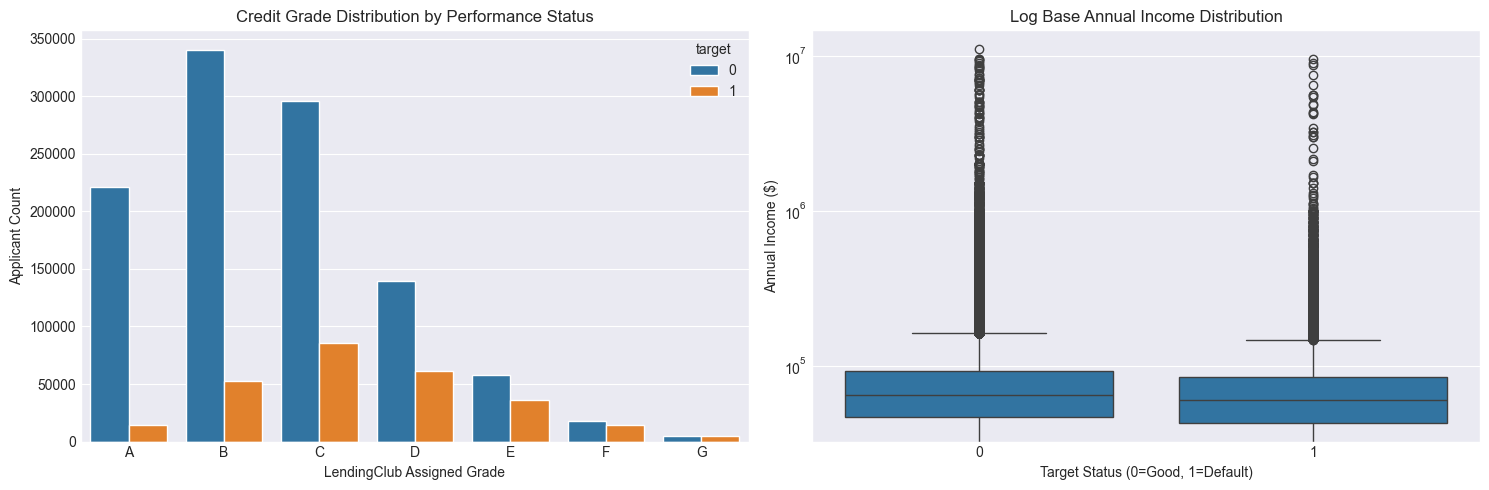

In [5]:
# Baseline Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of Credit Grades across Target Cohorts
sns.countplot(data=df_filtered, x='grade', hue='target', order=sorted(df_filtered['grade'].dropna().unique()), ax=axes[0])
axes[0].set_title("Credit Grade Distribution by Performance Status")
axes[0].set_xlabel("LendingClub Assigned Grade")
axes[0].set_ylabel("Applicant Count")

# 2. Continuous Metric Inspection: Log Annual Income vs Target
sns.boxplot(data=df_filtered, x='target', y='annual_inc', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title("Log Base Annual Income Distribution")
axes[1].set_xlabel("Target Status (0=Good, 1=Default)")
axes[1].set_ylabel("Annual Income ($)")

plt.tight_layout()
plt.show()

In [6]:
# Parse issue_d ("Jan-2018" format) for temporal split
df_filtered['issue_d'] = pd.to_datetime(df_filtered['issue_d'], format='%b-%Y')

# Industry convention: hold out the most recent period as OOT
# Dev  = 2007–2016 (model development)
# OOT  = 2017–2018 (out-of-time monitoring — simulates real deployment)
dev_mask = df_filtered['issue_d'].dt.year <= 2016
df_dev = df_filtered[dev_mask].drop(columns=['issue_d'])
df_oot = df_filtered[~dev_mask].drop(columns=['issue_d'])

print(f"Dev cohort  : {len(df_dev):>10,} rows  |  default rate: {df_dev['target'].mean():.2%}")
print(f"OOT cohort  : {len(df_oot):>10,} rows  |  default rate: {df_oot['target'].mean():.2%}")
print(f"OOT share   : {len(df_oot) / len(df_filtered):.1%} of total")

# Save dev cohort — used by notebooks 02, 03, 04, 05
dev_path = os.path.join(PROCESSED_DATA_DIR, "01_cleaned_cohort.csv.gz")
df_dev.to_csv(dev_path, index=False, compression='gzip')

# Save OOT cohort — used by notebook 06 for genuine PSI monitoring
oot_path = os.path.join(PROCESSED_DATA_DIR, "01_oot_cohort.csv.gz")
df_oot.to_csv(oot_path, index=False, compression='gzip')

print(f"\nSaved: {dev_path}")
print(f"Saved: {oot_path}")

Dev cohort  :  1,119,711 rows  |  default rate: 19.70%
OOT cohort  :    225,639 rows  |  default rate: 21.29%
OOT share   : 16.8% of total

Saved: data/processed\01_cleaned_cohort.csv.gz
Saved: data/processed\01_oot_cohort.csv.gz
